In [1]:
# Import useful Libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, mean_squared_error, r2_score
from scipy.stats import loguniform
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool, cv

np.random.seed(42)

In [2]:
df = pd.read_csv('../Dataset/Dataset2.csv')
df.head()

,Department,Gender,HSC,SSC,Income,Hometown,Computer,Preparation,Gaming,Attendance,Job,English,Extra,Semester,Last,Overall
0,Business Administration,Male,4.17,4.84,"Low (Below 15,000)",Village,3,More than 3 Hours,0-1 Hour,80%-100%,No,3,Yes,6th,3.220,3.350
1,Business Administration,Female,4.92,5.00,"Upper middle (30,000-50,000)",City,3,0-1 Hour,0-1 Hour,80%-100%,No,3,Yes,7th,3.467,3.467
2,Business Administration,Male,5.00,4.83,"Lower middle (15,000-30,000)",Village,3,0-1 Hour,More than 3 Hours,80%-100%,No,4,Yes,3rd,4.000,3.720
3,Business Administration,Male,4.00,4.50,"High (Above 50,000)",City,5,More than 3 Hours,More than 3 Hours,80%-100%,No,5,Yes,4th,3.800,3.750
4,Business Administration,Female,2.19,3.17,"Lower middle (15,000-30,000)",Village,3,0-1 Hour,2-3 Hours,80%-100%,No,3,Yes,4th,3.940,3.940


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 493 entries, 0 to 492
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Department   493 non-null    object 
 1   Gender       493 non-null    object 
 2   HSC          493 non-null    float64
 3   SSC          493 non-null    float64
 4   Income       493 non-null    object 
 5   Hometown     493 non-null    object 
 6   Computer     493 non-null    int64  
 7   Preparation  493 non-null    object 
 8   Gaming       493 non-null    object 
 9   Attendance   493 non-null    object 
 10  Job          493 non-null    object 
 11  English      493 non-null    int64  
 12  Extra        493 non-null    object 
 13  Semester     493 non-null    object 
 14  Last         493 non-null    float64
 15  Overall      493 non-null    float64
dtypes: float64(4), int64(2), object(10)
memory usage: 61.8+ KB


In [8]:
df.describe()


,HSC,SSC,Computer,English,Last,Overall
count,493.000000,493.000000,493.000000,493.000000,493.000000,493.000000
mean,4.156775,4.767647,3.338742,3.569980,3.163888,3.188383
std,0.546504,0.349538,1.252988,0.870515,0.641475,0.591801
min,2.170000,3.000000,1.000000,1.000000,1.000000,1.000000
25%,3.830000,4.680000,3.000000,3.000000,2.810000,2.880000
50%,4.170000,4.940000,3.000000,4.000000,3.250000,3.270000
75%,4.500000,5.000000,4.000000,4.000000,3.670000,3.680000
max,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000


In [9]:
# No columns to drop in the new dataset
df.shape


(493, 16)

In [10]:
# Distinction is based on whether the column contains numbers (int or float)
columns = list(df.columns)

categoric_columns = []
numeric_columns = []

# Iterate over columns and check for numeric types
for column in columns:
    if pd.api.types.is_numeric_dtype(df[column]):  # Check if column contains numbers
        numeric_columns.append(column)
    else:
        categoric_columns.append(column)

print('Numerical features: ', numeric_columns)
print('Categorical features: ', categoric_columns)


Numerical features:  ['HSC', 'SSC', 'Computer', 'English', 'Last', 'Overall']
Categorical features:  ['Department', 'Gender', 'Income', 'Hometown', 'Preparation', 'Gaming', 'Attendance', 'Job', 'Extra', 'Semester']


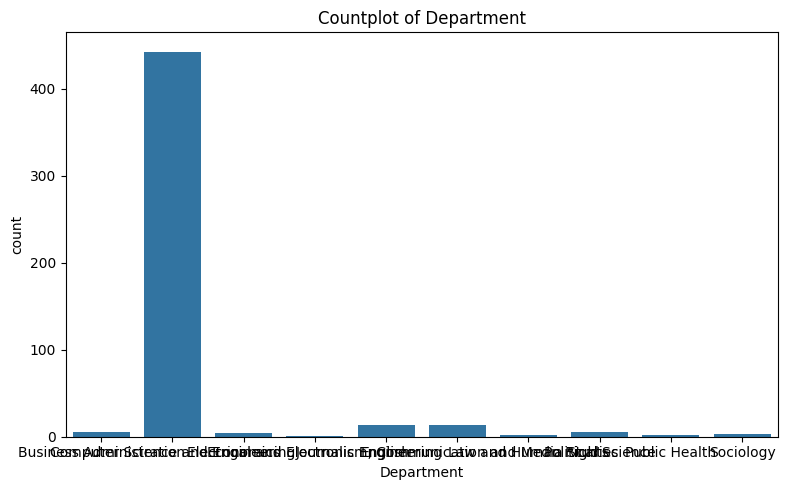

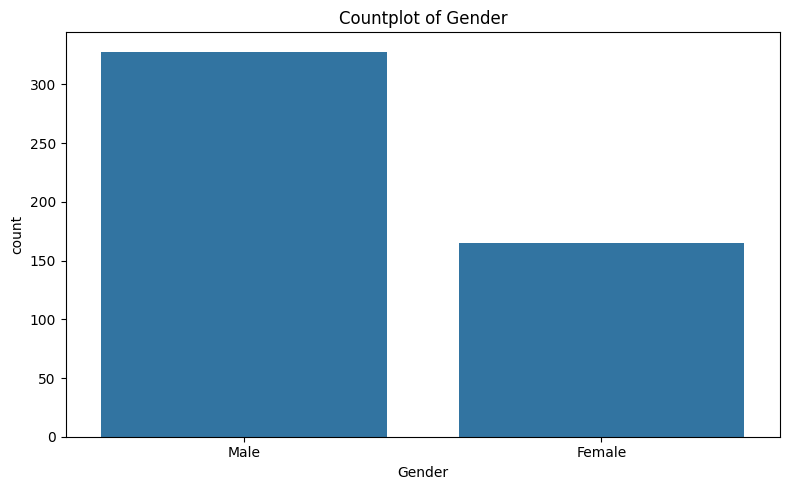

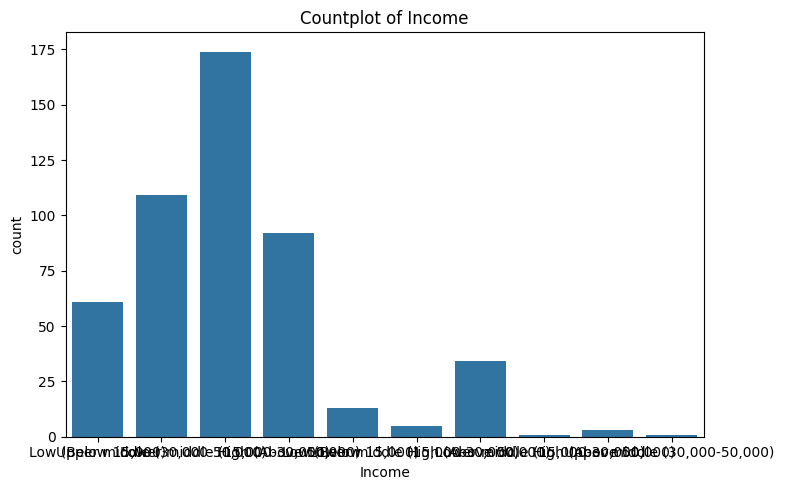

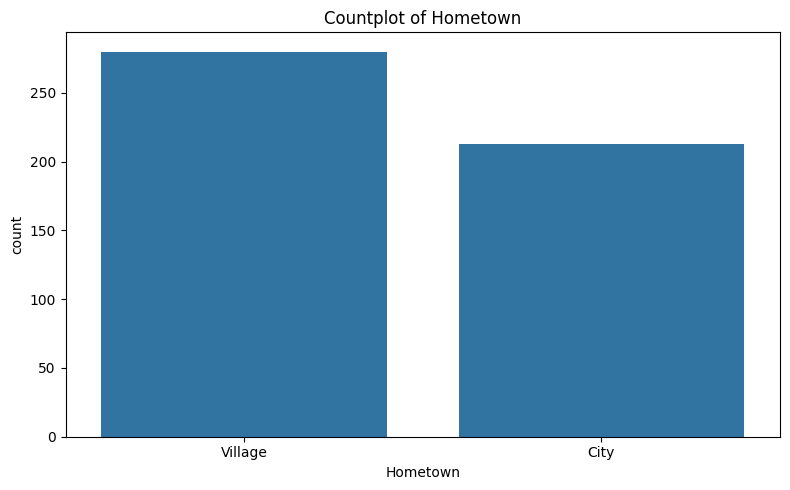

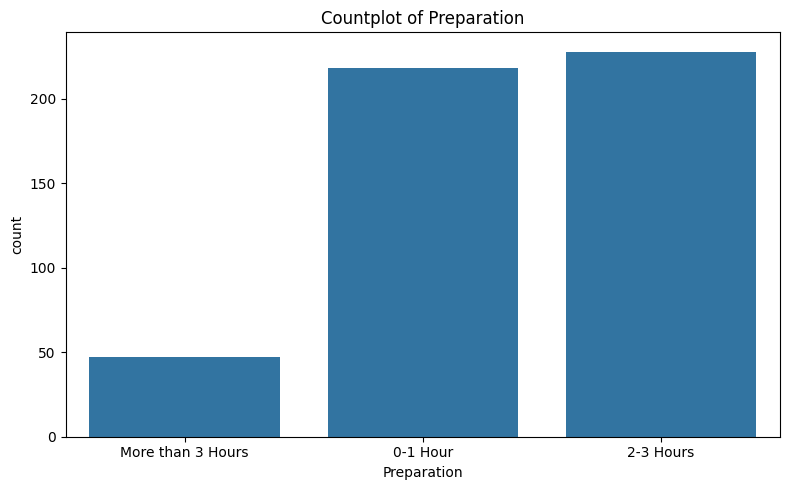

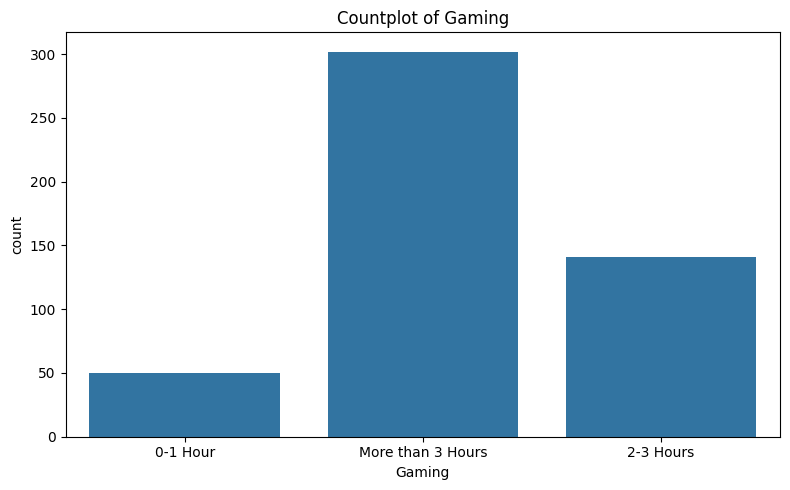

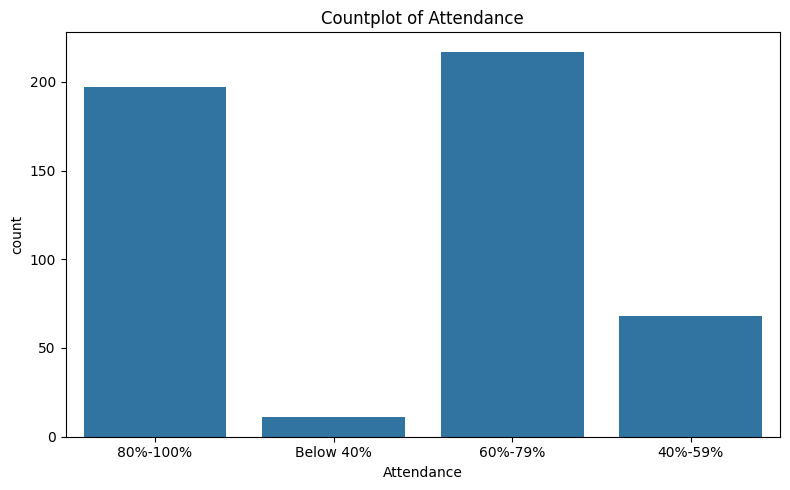

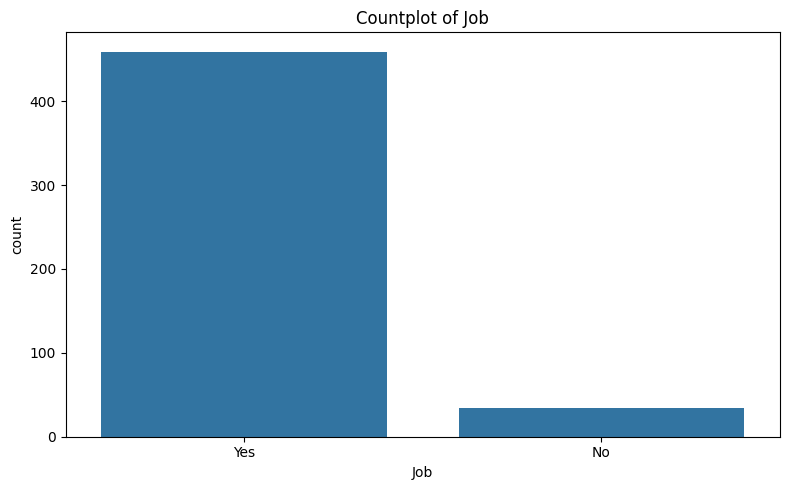

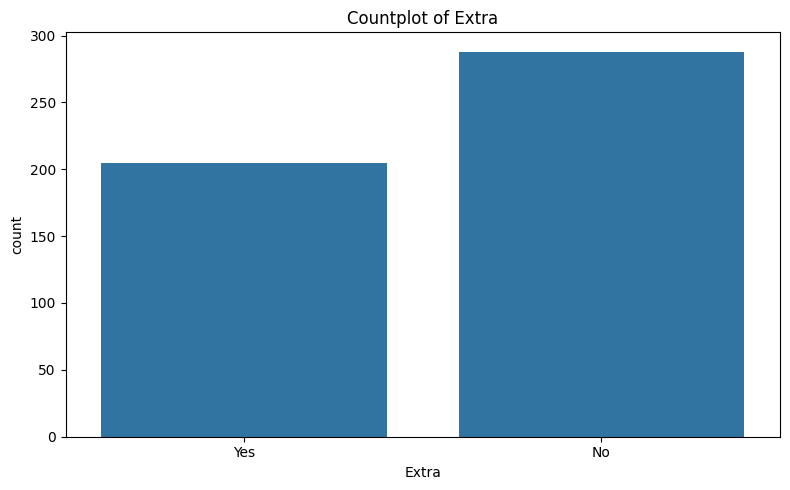

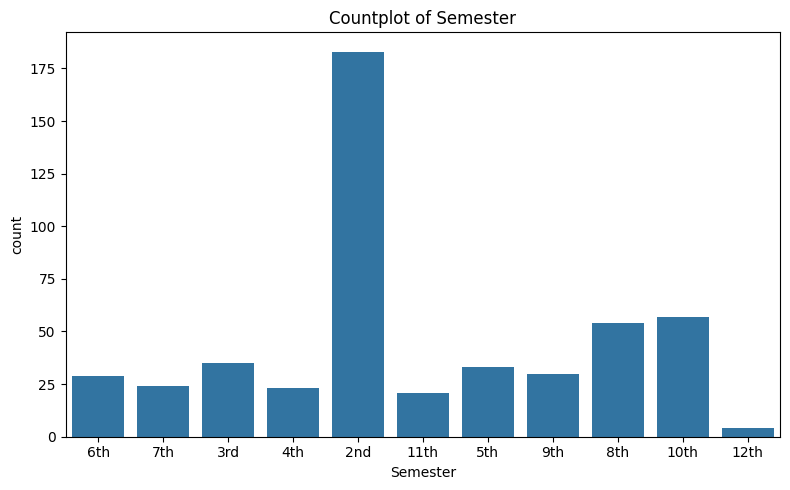

In [11]:
# Custom labels for the categorical columns in Dataset2
custom_labels = {
    'Department': df['Department'].unique().tolist(),
    'Gender': ['Male', 'Female'],
    'Income': df['Income'].unique().tolist(),
    'Hometown': df['Hometown'].unique().tolist(),
    'Preparation': df['Preparation'].unique().tolist(),
    'Gaming': df['Gaming'].unique().tolist(),
    'Attendance': df['Attendance'].unique().tolist(),
    'Job': ['Yes', 'No'],
    'Extra': ['Yes', 'No'],
    'Semester': df['Semester'].unique().tolist()
}

# Plot countplots for each categorical column
for column in categoric_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=column)
    plt.title(f'Countplot of {column}')

    # Set custom labels dynamically
    if column in custom_labels:
        labels = custom_labels[column]
        ticks = range(len(labels))
        plt.xticks(ticks=ticks, labels=labels)

    plt.tight_layout()
    plt.show()


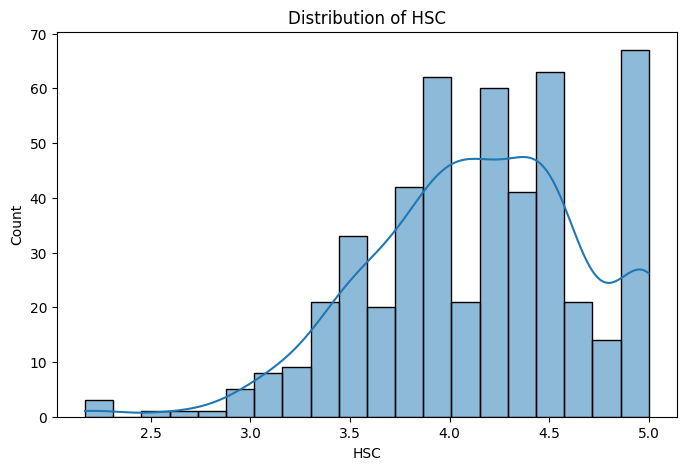

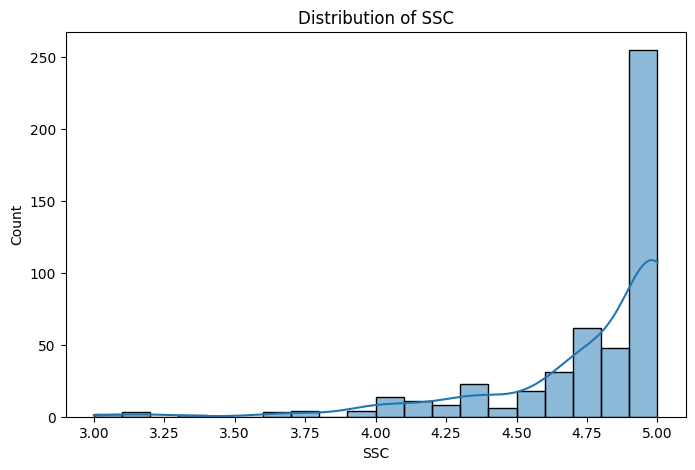

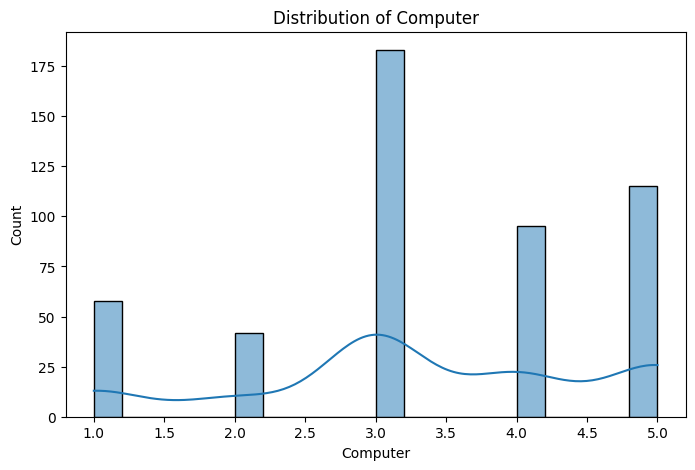

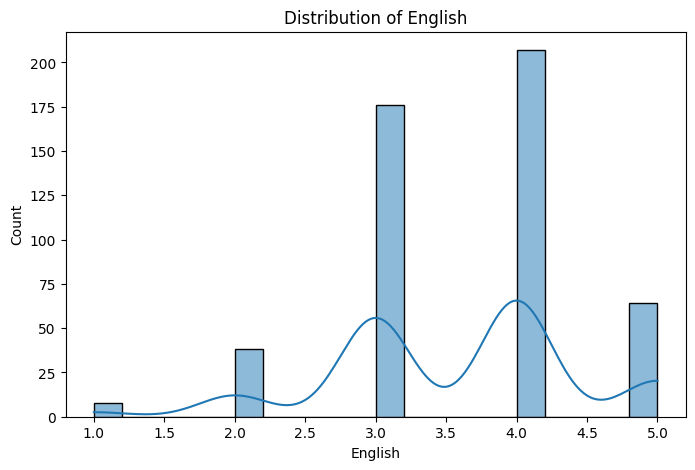

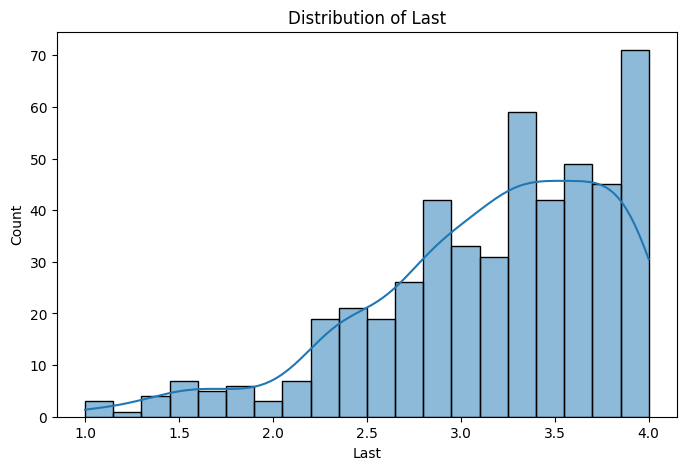

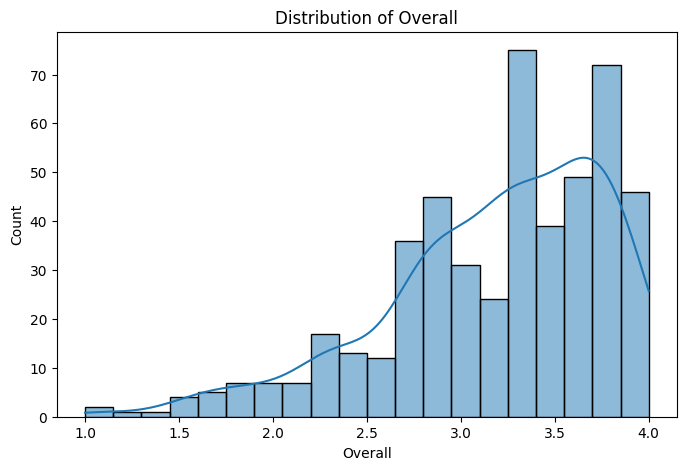

In [12]:
# Plot histogram for each numerical column
for column in numeric_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=column, kde=True, bins=20)
    plt.title(f'Distribution of {column}')
    plt.show()


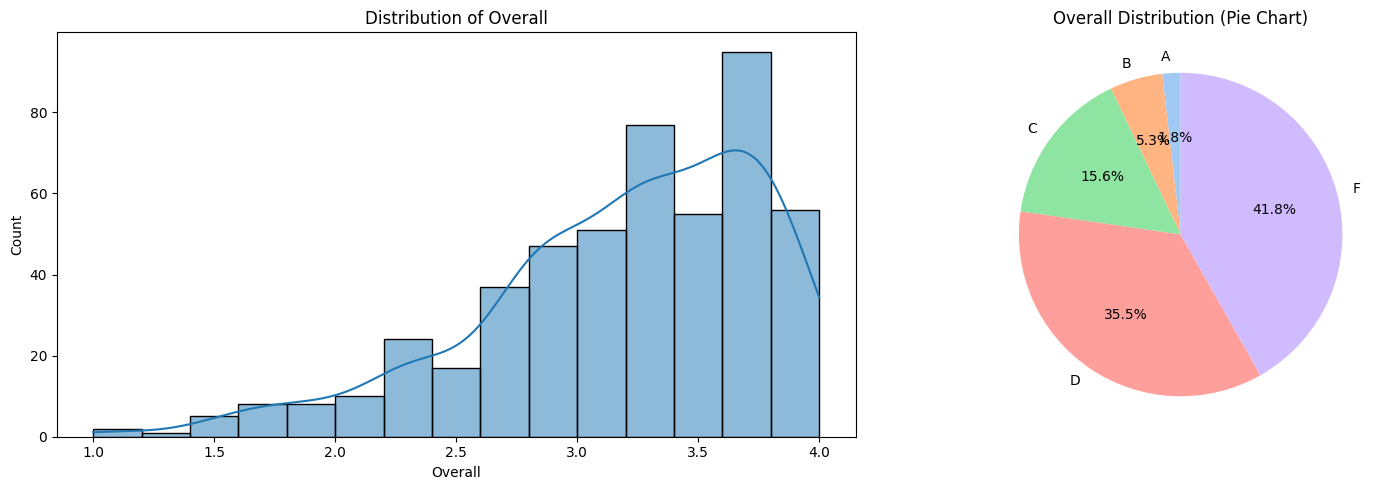

In [13]:
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot histogram for 'Overall'
sns.histplot(data=df, x='Overall', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Overall')

# Calculate counts for the pie chart
overall_bins = pd.cut(df['Overall'], bins=5, labels=['A', 'B', 'C', 'D', 'F'])
overall_counts = overall_bins.value_counts().sort_index()

# Plot the pie chart on the second subplot
axes[1].pie(overall_counts, labels=overall_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
axes[1].set_title('Overall Distribution (Pie Chart)')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()


In [14]:
df[numeric_columns] = df[numeric_columns].astype('float64')


In [15]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode categorical features
df = df.copy()
for column in df[categoric_columns]:  
    df[column] = label_encoder.fit_transform(df[column])

# Standardize numerical features
scaler = StandardScaler()
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

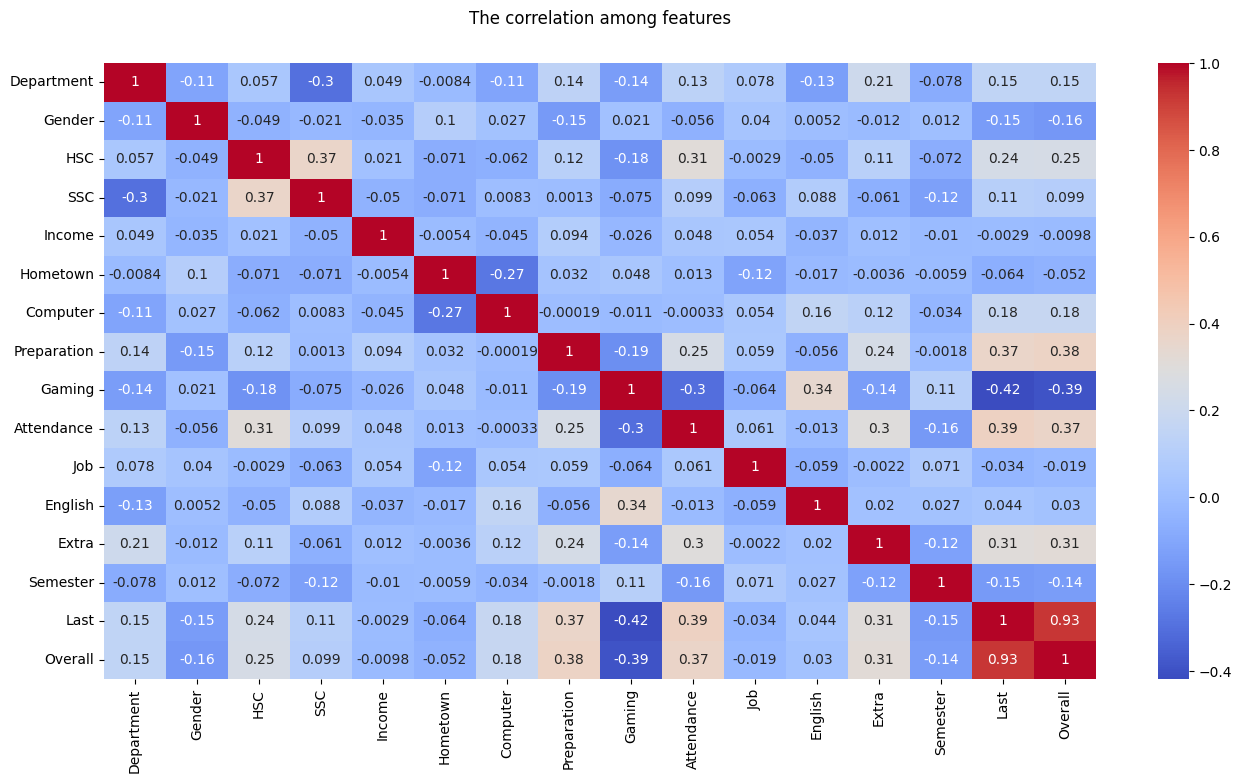

In [16]:
# Correlation heatmap after encoding and standardization
plt.figure(figsize=(16, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title('The correlation among features', y=1.05)
plt.show()


In [17]:
# Calculate the correlation with the 'Overall' and find the strongest correlation
overall_corr = df.corr(numeric_only=True)['Overall'].drop('Overall')
strongest_correlation = overall_corr.idxmax()
strongest_correlation_value = overall_corr.max()

print(f"The strongest correlation with Overall is {strongest_correlation} with a value of {strongest_correlation_value:.2f}")


The strongest correlation with Overall is Last with a value of 0.93


In [18]:
# Verify the encoded and standardized features
print("First 5 rows of the updated DataFrame:")
print(df.head())

print("\nSummary statistics for numerical columns:")
print(df[numeric_columns].describe())


First 5 rows of the updated DataFrame:
   Department  Gender       HSC       SSC  Income  Hometown  Computer  \
0           0       1  0.024224  0.207206       3         1 -0.270622   
1           0       0  1.397978  0.665419       8         0 -0.270622   
2           0       1  1.544511  0.178568       5         1 -0.270622   
3           0       1 -0.287160 -0.766495       0         0  1.327183   
4           0       0 -3.602485 -4.575387       5         1 -0.270622   

   Preparation  Gaming  Attendance  Job   English  Extra  Semester      Last  \
0            2       0           2    0 -0.655427      1         7  0.087562   
1            0       0           2    0 -0.655427      1         8  0.473003   
2            0       2           2    0  0.494486      1         4  1.304745   
3            2       2           2    0  1.644398      1         5  0.992647   
4            0       1           2    0 -0.655427      1         5  1.211116   

    Overall  
0  0.273370  
1  0.471273  

In [19]:
# CHOOSE THE TARGET FEATURE HERE, IN THIS CASE IT IS 'Overall'
X = df.drop(columns=['Overall'])
y = df['Overall']

# Splitting the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")


Training features shape: (394, 15)
Testing features shape: (99, 15)


In [20]:
# Dictionary of regression models
regression_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(),
    "Gradient Boosting Regressor": GradientBoostingRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
}

model_names = []
mse_scores = []
r2_scores = []

# Train and evaluate each model
for name, model in regression_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    model_names.append(name)
    mse_scores.append(mse)
    r2_scores.append(r2)
    print(f"{name} - MSE: {mse:.2f}, R2: {r2:.2f}")

# Create a DataFrame for model performance
df_models = pd.DataFrame({'Model': model_names, 'MSE': mse_scores, 'R2': r2_scores})

# Plot model performance using Plotly
fig = px.bar(df_models, x='Model', y='R2', title='Model R2 Scores')
fig.show()




Linear Regression - MSE: 0.12, R2: 0.89
Random Forest Regressor - MSE: 0.11, R2: 0.90
Gradient Boosting Regressor - MSE: 0.12, R2: 0.89
AdaBoost Regressor - MSE: 0.15, R2: 0.86


In [21]:
# Find the best model based on R² score
best_index = r2_scores.index(max(r2_scores))
best_model_name = model_names[best_index]
best_model = regression_models[best_model_name]

# Print the best model and its R² score
print(f"The best model is: {best_model_name} with an R² score of {r2_scores[best_index]:.2f}")


The best model is: Random Forest Regressor with an R² score of 0.90


In [22]:
# Define dynamic parameter grid for GridSearchCV
param_grids = {
    "LinearRegression": {},  # No hyperparameters for basic Linear Regression
    "RandomForestRegressor": {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    },
    "GradientBoostingRegressor": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    "AdaBoostRegressor": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0]
    },
}


# Automatically select the parameter grid for the best model
model_name = type(best_model).__name__

if model_name in param_grids:
    param_grid = param_grids[model_name]

    # Perform GridSearchCV
    grid_search = GridSearchCV(estimator=best_model, param_grid=param_grid, cv=5, scoring='r2', verbose=1)
    grid_search.fit(X_train, y_train)

    # Print best parameters and best score
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best cross-validation R² score: {grid_search.best_score_:.4f}")

    # Use the best model found by GridSearchCV for prediction
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Calculate and print R² and MSE on the test set
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f"R² score = {r2:.4f}, Mean Squared Error = {mse:.4f}")
else:
    print(f"No parameter grid defined for {model_name}.")



Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation R² score: 0.8649
R² score = 0.8931, Mean Squared Error = 0.1142
